# Module 4 - RAG pipeline

## Step 1 : Data Prepration & EDA

In [1]:
from datasets import load_dataset
import pandas as pd 
import numpy as np
import re
import os
import joblib
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.tokenize import sent_tokenize
import torch

c:\Users\win11\anaconda3\envs\rag-chatbot\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("Amod/mental_health_counseling_conversations")
df = pd.DataFrame(ds['train'])
df.head(3)

,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...


In [4]:
print("Before cleaning:\n")
# checking the number of Context & Response
print(f'Total Context & Response: {len(df)}')
print("="*50)

# checking the null values
print(f"Total null values: \n{df.isnull().sum()}")
print("="*50)

# checking duplicates
print(f"Duplicates rows: {df.duplicated().sum()}")
print(f"Duplicates Response: {df.duplicated(subset='Response').sum()}")
print(f"Duplicates Context: {df.duplicated(subset='Context').sum()}")
print("="*50)

Before cleaning:

Total Context & Response: 3512
Total null values: 
Context     0
Response    0
dtype: int64
Duplicates rows: 760
Duplicates Response: 1032
Duplicates Context: 2517


In [5]:
def clean_text(text):
    '''Clean text by removing URLs, HTML tags, extra spaces and newlines.'''
    text = str(text)

    # Remove HTML comments
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    # Remove quoted attribute values:  src="..."  or  src='...'  (with or without closing quote)
    text = re.sub(r'\w+\s*=\s*["\'][^"\']*["\']?', '', text)
    # Remove unquoted attribute values:  src=...
    text = re.sub(r'\w+\s*=\s*[^\s>"\']+', '', text)
    # Remove remaining tag shell  <...>  or  <...  (no closing >)
    text = re.sub(r'<[^>]*>?', '', text)

    # Remove URLs
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)
    text = re.sub(r'\b\S+\.(com|org|net|ca|io|pdf|html|htm)\S*', '', text)

    # Clean whitespace
    text = text.replace('\n', ' ')
    return re.sub(r'\s+', ' ', text).strip()

df['Context'] = df['Context'].apply(clean_text)
df['Response'] = df['Response'].apply(clean_text)

# Delete rows with empty Context or Response, drop short rows and duplicates
df = df[(df['Context'] != "") & (df['Response'] != "")]
df = df[df['Context'].str.len() >= 15]
df = df[df['Response'].str.len() >= 15]
df = df.drop_duplicates()

In [6]:
print("After cleaning:\n")

# checking the number of Context & Response
print(f'Total Context & Response: {len(df)}')
print("="*50)

# checking the null values
print(f"Total null values: \n{df.isnull().sum()}")
print("="*50)

# checking duplicates
print(f"Duplicates rows: {df.duplicated().sum()}")
print(f"Duplicates Response: {df.duplicated(subset='Response').sum()}")
print(f"Duplicates Context: {df.duplicated(subset='Context').sum()}")
print("="*50)

After cleaning:

Total Context & Response: 2021
Total null values: 
Context     0
Response    0
dtype: int64
Duplicates rows: 0
Duplicates Response: 1
Duplicates Context: 1191


In [7]:
# There are some 'Contexts' that have multiple 'Responses'.
dup_context = df.groupby('Context')['Response'].nunique().sort_values(ascending=False)
dup_context[dup_context > 1]

Context
I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac. I have a long history of depression and I’m beginning to have anxiety. I have low self esteem but I’ve been happily married for almost 35 years. I’ve never had counseling about any of this. Do I have too many issues to address in counseling?                                                                                                                                                                                                                                                                                                                                                                                                           47
How do you know you have the right therapist for you? How would I know how to "train" my therapist to be able to give me what I need from treatment?                                                                             

In [8]:
conflicts = (
    df.groupby('Context')
      .filter(lambda x: x['Response'].nunique() > 1)
      .sort_values('Context')
)

with open("conflicts_output.txt", "w", encoding="utf-8") as f:
    for context, group in conflicts.groupby('Context'):
        f.write("=" * 80 + "\n")
        f.write("CONTEXT:\n\n")
        f.write(str(context) + "\n")

        f.write("\nRESPONSES:\n\n")
        for i, response in enumerate(group['Response'].unique(), 1):
            f.write(f"{i}. {response}\n\n")

print("Saved to conflicts_output.txt")

Saved to conflicts_output.txt


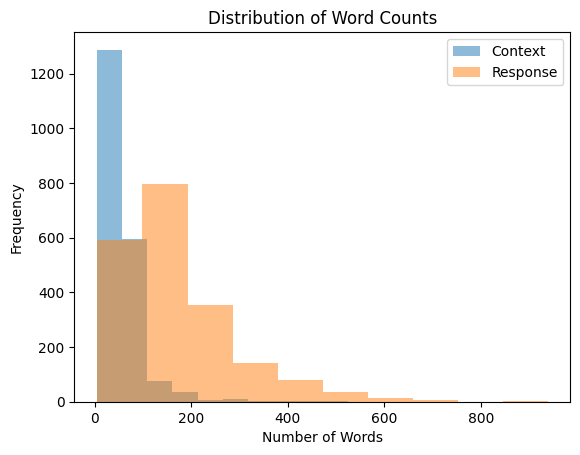

In [9]:
# draw distribution of number of words in Context and Response
import matplotlib.pyplot as plt

df['Context_word_count'] = df['Context'].apply(lambda x: len(x.split()))
df['Response_word_count'] = df['Response'].apply(lambda x: len(x.split()))

# plot distributions
plt.hist(df['Context_word_count'], alpha=0.5, label='Context')
plt.hist(df['Response_word_count'], alpha=0.5, label='Response')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts')
plt.legend()
plt.show()

In [10]:
# saving the cleaned dataframe to a csv file in data folder
df.to_csv('data/df_cleaned.csv', index=False)

### Handle mutiple Response of the same Context

#### Clustering-based Summarization

In [11]:
# Making embeddings for clustering and summarization

# Load embedding model
model = SentenceTransformer('all-mpnet-base-v2')

# Precompute embeddings for all unique responses and cache to disk
emb_cache_path = os.path.join('data', 'response_embeddings.joblib')
responses = df['Response'].unique().tolist()

if os.path.exists(emb_cache_path):
    emb_lookup = joblib.load(emb_cache_path)
    print(f'Loaded cached embeddings for {len(emb_lookup)} responses')
else:
    print(f'Computing embeddings for {len(responses)} unique responses...')
    emb_array = model.encode(
        responses,
        convert_to_numpy=True,
        normalize_embeddings=True,
        batch_size=64,
        show_progress_bar=True
    )
    emb_lookup = {r: emb_array[i] for i, r in enumerate(responses)}
    os.makedirs(os.path.dirname(emb_cache_path), exist_ok=True)
    joblib.dump(emb_lookup, emb_cache_path)
    print(f'Saved embeddings cache to {emb_cache_path}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2274.35it/s]


Computing embeddings for 2020 unique responses...


Batches: 100%|██████████| 32/32 [12:43<00:00, 23.86s/it]


Saved embeddings cache to data\response_embeddings.joblib


In [12]:
def semantic_clustering_summarize(responses, emb_lookup, similarity_threshold=0.75):
    """ Cluster similar responses and return a representative response for each cluster.
    Args:
        responses (list): List of responses to cluster.
        emb_lookup (dict): Mapping response -> embedding (numpy array).
        similarity_threshold (float): Threshold for cosine similarity to consider responses as similar.
    Returns:
        list: List of representative responses for each cluster.
    """
    # if there is only one response
    if len(responses) <= 1:
        return responses

    # Build embeddings matrix from lookup; fall back to encoding missing responses
    missing = [r for r in responses if r not in emb_lookup]
    if missing:
        # encode missing ones on-the-fly
        missing_embs = model.encode(missing, convert_to_numpy=True, normalize_embeddings=True, batch_size=64, show_progress_bar=False)
        for i, r in enumerate(missing):
            emb_lookup[r] = missing_embs[i]

    embeddings = np.vstack([emb_lookup[r] for r in responses])

    # Clustering
    clustering_model = AgglomerativeClustering(n_clusters=None, metric='cosine', linkage='average', distance_threshold=1 - similarity_threshold)
    labels = clustering_model.fit_predict(embeddings)

    # Pick representative response
    unique_views = []

    for cluster_id in np.unique(labels):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_embeddings = embeddings[cluster_indices]

        # centroid of cluster
        centroid = cluster_embeddings.mean(axis=0)
        # normalize centroid to unit length (avoid zero division)
        norm = np.linalg.norm(centroid)
        if norm > 0:
            centroid = centroid / (norm + 1e-12)

        # similarity to centroid
        similarities = cosine_similarity(cluster_embeddings, centroid.reshape(1, -1)).flatten()

        # best representative
        best_local_idx = np.argmax(similarities)
        best_idx = cluster_indices[best_local_idx]
        unique_views.append(responses[best_idx])

    return unique_views

In [13]:
final_data = []

# Process each Context (with progress bar)
for context, group in tqdm(df.groupby('Context'), total=df['Context'].nunique()):
    raw_responses = group['Response'].unique().tolist()
    summarized_views = semantic_clustering_summarize(raw_responses, emb_lookup, similarity_threshold=0.65)

    # Guard against empty summarization
    if not summarized_views:
        summarized_views = raw_responses[:1]

    # Format responses
    formatted_responses = (
        "\n".join([f"• {r}" for r in summarized_views])
        if len(summarized_views) > 1
        else summarized_views[0])

    final_data.append({'Context': context, 'Responses': formatted_responses})

# Save final dataframe
summarized_df = pd.DataFrame(final_data)
out_path = os.path.join('data', 'semantic_clustered_rag.csv')
summarized_df.to_csv(out_path, index=False)
print(f'Saved summarized dataframe to {out_path}')
summarized_df.head()

  0%|          | 0/830 [00:00<?, ?it/s]

100%|██████████| 830/830 [00:01<00:00, 804.68it/s]


Saved summarized dataframe to data\semantic_clustered_rag.csv


,Context,Responses
0,A few nights ago I talked to this girl I know ...,Hey! It takes a lot of courage to share your f...
1,A few years ago I was making love to my wife w...,"• For starters, know that this is a normal exp..."
2,A friend of mine taking psychology advised I g...,I admire your courage for stating your view ab...
3,A girl and I were madly in love. We dated for ...,"Hi Boise, I'm sorry that you've lost this love..."
4,"A lot of times, I avoid situations where I am ...",• Why not accept and tolerate that you natural...


In [14]:
# show max number of bullets in each row of  response of summarized_df
summarized_df['num_bullets'] = summarized_df['Responses'].apply(lambda x: x.count('•'))
max_bullets = summarized_df['num_bullets'].max()
print(f'Maximum number of bullets in Responses: {max_bullets}')
# showing top 10 rows with most responses (bullets)
top_10_bullets = summarized_df.nlargest(10, 'num_bullets')
print("\nTop 10 Rows with Most Bullets:")
print(top_10_bullets[['Responses', 'num_bullets']])


Maximum number of bullets in Responses: 12

Top 10 Rows with Most Bullets:
                                             Responses  num_bullets
283  • It's not really a question of whether you ha...           12
456  • I first want to let you know that you are no...            8
685  • It is difficult to implement healthy boundar...            7
812  • It's totally normal to feel overwhelmed and ...            7
154  • What exactly is it that you are looking for?...            6
307  • First off, there is nothing wrong with you. ...            6
438  • I am so sorry this is happening to you. One ...            6
518  • Yes, feeling nervous for the first few or se...            6
554  • Have you used meditation or hypnosis? Relaxi...            6
817  • I understand that as a mom it must be really...            6


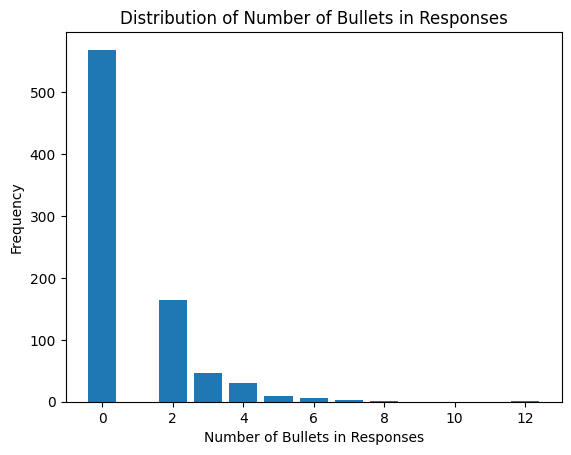

In [15]:
# visualize distribution of number of bullets in Responses
plt.hist(summarized_df['num_bullets'], bins=range(0, max_bullets + 2), align='left', rwidth=0.8)
plt.xlabel('Number of Bullets in Responses')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Bullets in Responses')
plt.show()

## Step 2 : Context Indexing

In [ ]:
# import os
# os.remove('data/chunks.parquet')
# os.remove('artifacts/chunk_embeddings.joblib') 
# os.remove('artifacts/index_metadata.joblib')  

In [17]:
# Indexing Config
# One vector per (context, response) pair.
# The CONTEXT is embedded; the clustered RESPONSE is stored as payload.
# No chunking needed: contexts are short (median ~59 tokens, well within 512).

BATCH_SIZE = 64
MODEL_NAME = 'all-mpnet-base-v2'

OUT_INDEX  = os.path.join('data',      'context_index.parquet')
OUT_EMB    = os.path.join('artifacts', 'context_vec_embeddings.joblib')
OUT_META   = os.path.join('artifacts', 'context_index_metadata.joblib')

print('Indexing config ready.')
print(f'  Strategy : embed Context, store Response as payload')
print(f'  Model    : {MODEL_NAME}')

Indexing config ready.
  Strategy : embed Context, store Response as payload
  Model    : all-mpnet-base-v2


In [18]:
def split_bullets(text):
    """
    Split a Responses field into individual therapist answers.
    Handles bullet markers: •  -  *  1.  and newlines.
    """
    if not text:
        return []
    parts = re.split(r'\n+', str(text))
    bullets = []
    for p in parts:
        s = p.strip()
        if not s:
            continue
        s = re.sub(r'^\s*(?:•|\-|\*|\d+\.)\s*', '', s)
        s = s.strip()
        if s:
            bullets.append(s)
    return bullets

def truncate_response(text, max_words=310):
    """
    Cap a response at ~400 tokens (≈310 words) cutting at a sentence boundary.
    Keeps the LLM prompt budget predictable without losing the core advice.
    """
    words = text.split()
    if len(words) <= max_words:
        return text
    truncated = ' '.join(words[:max_words])
    last_period = truncated.rfind('.')
    return truncated[:last_period + 1] if last_period > 50 else truncated

In [20]:
# Load the semantic-clustered output from Step 1
chunking_df = pd.read_csv(os.path.join('data', 'semantic_clustered_rag.csv'))
print(f'Loaded {len(chunking_df):,} rows')
print(f'Columns: {chunking_df.columns.tolist()}')

Loaded 830 rows
Columns: ['Context', 'Responses']


In [21]:
# One record per (context, therapist-response-bullet).
# The CONTEXT is what will be embedded into the vector space.
# The response bullet is stored as payload and retrieved at query time.

records = []
for i, row in tqdm(chunking_df.iterrows(), total=len(chunking_df), desc='Building index records'):
    context    = str(row.get('Context', row.iloc[0])).strip()
    resp_field = row.get('Responses') if 'Responses' in chunking_df.columns else row.get('Response')

    bullets = split_bullets(resp_field) if resp_field else []
    if not bullets:
        bullets = [resp_field] if resp_field else [context]

    for bi, bullet in enumerate(bullets):
        records.append({
            'context_id'       : int(i),
            'bullet_index'     : int(bi),
            'context'          : context,                    # will be embedded
            'original_response': truncate_response(bullet),  # payload
        })

index_df = pd.DataFrame(records)
print(f'Summarized rows  : {len(chunking_df):,}')
print(f'Total index rows : {len(index_df):,}  (one per context-response pair)')
index_df.head(3)

Building index records: 100%|██████████| 830/830 [00:00<00:00, 976.48it/s] 

Summarized rows  : 830
Total index rows : 1,279  (one per context-response pair)


,context_id,bullet_index,context,original_response
0,0,0,A few nights ago I talked to this girl I know ...,Hey! It takes a lot of courage to share your f...
1,1,0,A few years ago I was making love to my wife w...,"For starters, know that this is a normal exper..."
2,1,1,A few years ago I was making love to my wife w...,Assuming there are no medical explanations for...


In [22]:
index_df['context_tokens_est'] = index_df['context'].str.split().str.len().mul(1.3).astype(int)
index_df['response_words']     = index_df['original_response'].str.split().str.len()

print('Context estimated-token stats (limit = 512):')
print(index_df['context_tokens_est'].describe().round(1))
print(f"Over 512 tokens : {(index_df['context_tokens_est'] > 512).sum()} rows  "
      f"({(index_df['context_tokens_est'] > 512).mean()*100:.1f}%)")
print()
print('Response word-count stats (after truncation):')
print(index_df['response_words'].describe().round(1))


Context estimated-token stats (limit = 512):
count    1279.0
mean       77.8
std        68.3
min         6.0
25%        40.0
50%        63.0
75%        91.0
max       683.0
Name: context_tokens_est, dtype: float64
Over 512 tokens : 7 rows  (0.5%)

Response word-count stats (after truncation):
count    1279.0
mean      153.8
std        80.4
min         6.0
25%        91.0
50%       138.0
75%       212.0
max       310.0
Name: response_words, dtype: float64


In [23]:
# Save index records for Step 3 upload
os.makedirs('data', exist_ok=True)
os.makedirs('artifacts', exist_ok=True)
index_df.to_parquet(OUT_INDEX, index=False)
print(f'Saved {len(index_df):,} index records → {OUT_INDEX}')

Saved 1,279 index records → data\context_index.parquet


In [24]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Loading embedding model: {MODEL_NAME} on {device}...')
embed_model = SentenceTransformer(MODEL_NAME, device=device)

# Embed the CONTEXT column — this is what the user's query will be compared against.
contexts_to_embed = index_df['context'].tolist()
emb_list = []

for i in tqdm(range(0, len(contexts_to_embed), BATCH_SIZE), desc='Embedding contexts'):
    batch = contexts_to_embed[i : i + BATCH_SIZE]
    emb   = embed_model.encode(
        batch,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    emb_list.append(emb)

embeddings = np.vstack(emb_list)
print(f'Embeddings shape: {embeddings.shape}  (one vector per context-response pair)')


Loading embedding model: all-mpnet-base-v2 on cpu...


Embedding contexts: 100%|██████████| 20/20 [06:19<00:00, 18.97s/it]

Embeddings shape: (1279, 768)  (one vector per context-response pair)


In [25]:
joblib.dump(embeddings,  OUT_EMB)
joblib.dump(index_df.to_dict(orient='records'), OUT_META)

print(f'Saved embeddings → {OUT_EMB}   shape={embeddings.shape}')
print(f'Saved metadata   → {OUT_META}  records={len(index_df):,}')

Saved embeddings → artifacts\context_vec_embeddings.joblib   shape=(1279, 768)
Saved metadata   → artifacts\context_index_metadata.joblib  records=1,279


In [35]:
# Quick check: retrieve nearest context to a sample query
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

sample_query = "I feel depressed and anxious all the time. I want to talk to someone but I don't know where to start."
q_emb = embed_model.encode([sample_query], normalize_embeddings=True)
scores = cos_sim(q_emb, embeddings)[0]
top_idx = scores.argsort()[::-1][:5]

print(f'Query: "{sample_query}"\n')
for rank, idx in enumerate(top_idx, 1):
    rec = index_df.iloc[idx]
    print(f'--- Rank {rank}  (score={scores[idx]:.4f}) ---')
    print(f'Matched context : {rec["context"][:150]}')
    print(f'Stored response : {rec["original_response"][:200]}')
    print()

Query: "I feel depressed and anxious all the time. I want to talk to someone but I don't know where to start."

--- Rank 1  (score=0.8214) ---
Matched context : I'm very depressed. How do I find someone to talk to?
Stored response : Great that you realize talking with a professional counselor about how you feel, would be helpful!If you'd like a very fast response by phone, then google "depression hotline" for where you live. And,

--- Rank 2  (score=0.8214) ---
Matched context : I'm very depressed. How do I find someone to talk to?
Stored response : If there is no one in your life with whom you feel comfortable, I would recommend identifying someone on this site, psychology today or who is in your area, then give that therapist a call to see if y

--- Rank 3  (score=0.8214) ---
Matched context : I'm very depressed. How do I find someone to talk to?
Stored response : You have already taken the brave first step of making the decision to heal from it and find a professional that will help

## Step 3 : Store in VectorDB

In [36]:
from qdrant_client import QdrantClient
from dotenv import load_dotenv
load_dotenv()

# Initialize Qdrant client using environment variables for URL and API key
qdrant_client = QdrantClient(
    url     = os.getenv("QDRANT_URL"),
    api_key = os.getenv("QDRANT_API_KEY"),
)

In [37]:
# Recreate collection — vectors are context embeddings (768-dim, cosine)
from qdrant_client.http.models import Distance, VectorParams
qdrant_client.recreate_collection(
    collection_name="mental_health_rag",
    vectors_config=VectorParams(
        size=768,
        distance=Distance.COSINE,
    ),
)

C:\Users\win11\AppData\Local\Temp\ipykernel_4716\1035582834.py:3: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qdrant_client.recreate_collection(


True

In [38]:
from qdrant_client.http.models import PointStruct
import time

# Load saved context embeddings and index records
embeddings = joblib.load(OUT_EMB)
metadata   = joblib.load(OUT_META)

# Each point: vector = context embedding, payload = context text + response
points = [
    PointStruct(
        id=idx,
        vector=embeddings[idx].astype('float32').tolist(),
        payload={
            "context_id"        : rec["context_id"],
            "bullet_index"      : rec["bullet_index"],
            "context"           : rec["context"],           # for reranker input
            "original_response" : rec["original_response"],  # returned to LLM
        }
    )
    for idx, rec in enumerate(metadata)
]

# Upload in batches with retry logic
BATCH = 32
for i in tqdm(range(0, len(points), BATCH), desc='Uploading to Qdrant'):
    batch = points[i : i + BATCH]
    for attempt in range(3):
        try:
            qdrant_client.upsert(
                collection_name="mental_health_rag",
                points=batch,
                wait=False)
            break
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            time.sleep(2)

print(f"Uploaded {len(points):,} points to 'mental_health_rag'")


Uploading to Qdrant:  20%|██        | 8/40 [00:49<03:17,  6.18s/it]

Attempt 1 failed: The write operation timed out


Uploading to Qdrant:  40%|████      | 16/40 [01:54<03:08,  7.84s/it]

Attempt 1 failed: The write operation timed out
Attempt 2 failed: The write operation timed out


Uploading to Qdrant:  45%|████▌     | 18/40 [02:22<03:47, 10.35s/it]

...

Attempt 1 failed: The write operation timed out


Uploading to Qdrant:  80%|████████  | 32/40 [04:13<01:00,  7.54s/it]

Attempt 1 failed: The write operation timed out


Uploading to Qdrant: 100%|██████████| 40/40 [05:07<00:00,  7.68s/it]

Uploaded 1,279 points to 'mental_health_rag'


In [39]:
# Verify count in Qdrant matches number of points uploaded
info = qdrant_client.get_collection("mental_health_rag")
print(f'Vectors in Qdrant : {info.points_count:,}')
print(f'Expected          : {len(points):,}')
assert info.points_count == len(points), 'Mismatch! Some points may not have uploaded.'

Vectors in Qdrant : 1,279
Expected          : 1,279


In [40]:
# Quick check: retrieve nearest context to a query using Qdrant
if 'embed_model' not in dir():
    embed_model = SentenceTransformer(MODEL_NAME)

sample_query = 'I feel hopeless and do not know what to do'

q_emb = embed_model.encode(
    [sample_query],
    normalize_embeddings=True
)[0].tolist()

results = qdrant_client.query_points(
    collection_name="mental_health_rag",
    query=q_emb,
    limit=3,
    with_payload=True,
)

print(f'Query: "{sample_query}"\n')
for rank, r in enumerate(results.points, 1):
    print(f'--- Rank {rank} (score={r.score:.4f}) ---')
    print(f'Matched context : {r.payload["context"][:150]}')
    print(f'Stored response : {r.payload["original_response"][:200]}')
    print()


Query: "I feel hopeless and do not know what to do"

--- Rank 1 (score=0.5715) ---
Matched context : My motivation has gone away. It's hard to get out of bed. I really don't know what to do anymore. I'm miserable. My anxiety and depression have taken 
Stored response : It is challenging to maintain motivation at all times, anxiety and depression can set in which can make interacting with others a struggle, it can lead us to do things that make us not feel good and w

--- Rank 2 (score=0.5715) ---
Matched context : My motivation has gone away. It's hard to get out of bed. I really don't know what to do anymore. I'm miserable. My anxiety and depression have taken 
Stored response : One of the first steps is to manage anxiety and depression symptoms are to establish a good self-care routine. Start with the most basic things: Eating balanced meals, sleeping at from 6-8 hours and e

--- Rank 3 (score=0.5428) ---
Matched context : I was in a car accident and totaled my car. I gave up my job 

In [41]:
from rank_bm25 import BM25Okapi

# BM25 also indexes CONTEXT text so both retrievers operate in the same space.
# Position in this list == Qdrant point id (uploaded with id=idx).
index_records    = pd.read_parquet(OUT_INDEX)
bm25_texts       = index_records['context'].tolist()
tokenized_corpus = [text.lower().split() for text in bm25_texts]
bm25_index       = BM25Okapi(tokenized_corpus)

print(f'BM25 index built on {len(bm25_texts):,} context documents')

BM25 index built on 1,279 context documents


## Step 4 : Hybrid Retrieval (Semantic 0.7 + BM25 0.3)

In [44]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

SEMANTIC_WEIGHT = 0.7
BM25_WEIGHT     = 0.3
CANDIDATE_POOL  = 50   # candidates fed into the reranker


def _normalize(score_dict):
    if not score_dict:
        return {}
    values = list(score_dict.values())
    lo, hi = min(values), max(values)
    if hi == lo:
        return {k: 1.0 for k in score_dict}
    return {k: (v - lo) / (hi - lo) for k, v in score_dict.items()}


def retrieve_responses_hybrid(query_text, top_k=5, rerank_pool=20):
    """
    Hybrid retrieval pipeline:

    1. Semantic  → embed query, find top CANDIDATE_POOL nearest CONTEXTS in Qdrant
    2. BM25      → keyword match against CONTEXT texts, take top CANDIDATE_POOL
    3. Union     → merge both candidate sets
    4. Normalize → scale scores to [0,1] independently
    5. Combine   → final = 0.7 * sem_norm + 0.3 * bm25_norm
    6. Reranker  → CrossEncoder scores (query, context) pairs for rerank_pool candidates
                   — picks the most semantically relevant contexts
    7. Return    → the stored `original_response` payload for the top_k winners
    """
    # ── 1. Semantic ──────────────────────────────────────────────────────────
    q_emb = embed_model.encode([query_text], normalize_embeddings=True)[0].tolist()
    semantic_hits = qdrant_client.query_points(
        collection_name="mental_health_rag",
        query=q_emb,
        limit=CANDIDATE_POOL,
        with_payload=True,
    )
    semantic_scores = {r.id: r.score for r in semantic_hits.points}

    # ── 2. BM25 ──────────────────────────────────────────────────────────────
    tokenized_query = query_text.lower().split()
    bm25_all_scores = bm25_index.get_scores(tokenized_query)
    bm25_top_ids    = np.argsort(bm25_all_scores)[::-1][:CANDIDATE_POOL]
    bm25_scores     = {int(i): float(bm25_all_scores[i]) for i in bm25_top_ids}

    # ── 3. Union & 4. Normalize ──────────────────────────────────────────────
    all_ids   = set(semantic_scores.keys()) | set(bm25_scores.keys())
    sem_norm  = _normalize(semantic_scores)
    bm25_norm = _normalize(bm25_scores)

    # ── 5. Combine ───────────────────────────────────────────────────────────
    combined = sorted(
        [(cid, SEMANTIC_WEIGHT * sem_norm.get(cid, 0.0) + BM25_WEIGHT * bm25_norm.get(cid, 0.0))
         for cid in all_ids],
        key=lambda x: x[1], reverse=True
    )
    top_ids = [cid for cid, _ in combined[:rerank_pool]]

    # ── 6. Fetch payloads & rerank on (query, context) pairs ─────────────────
    fetched = qdrant_client.retrieve(
        collection_name="mental_health_rag",
        ids=top_ids,
        with_payload=True,
    )
    id_to_payload = {r.id: r.payload for r in fetched}

    # Reranker sees (query, context) — NOT the response.
    # This decides which contexts are most relevant; response is the returned payload.
    valid_ids    = [cid for cid in top_ids if cid in id_to_payload]
    rerank_pairs = [(query_text, id_to_payload[cid]["context"]) for cid in valid_ids]
    rerank_scores = reranker.predict(rerank_pairs)

    ranked = sorted(
        zip(valid_ids, rerank_scores),
        key=lambda x: x[1], reverse=True
    )[:top_k]

    # ── 7. Return the stored responses for the top_k reranked contexts ────────
    return [id_to_payload[cid]["original_response"] for cid, _ in ranked]


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5250.26it/s]


### Testing Retrieval

In [45]:
query   = "I feel sad and do not know what to do"
results = retrieve_responses_hybrid(query, top_k=3)

print(f'Query: "{query}"\n')
for i, response in enumerate(results, 1):
    print(f"--- Rank {i} ---")
    print(response[:300])
    print()

Query: "I feel sad and do not know what to do"

--- Rank 1 ---
It sounds like you have several different things happening at the same time. I would encourage you to call and speak to a local therapist. If you are having thoughts of killing yourself in this moment, please call 800-273-8255 and talk to someone.While I follow that you would like your son to be una

--- Rank 2 ---
Understandably the idea of someone who tries to control you, is good reason to feel sad.Your feelings sound like they are very strong and meaningful in your life.Keep in mind that your feelings about others has more to do with one's own self-view than with what the other person is actually doing.Unl

--- Rank 3 ---
Hello,While one can be sad from time to time, feeling sad "all the time" could be a sign of depression. If you feel sad on most days, it is worthwhile speaking to a psychologist to determine whether you suffer clinical depression. Feeling sadness is a normal response to loss, whether you lose a fami



## Step 5 : Response

In [46]:
from openai import OpenAI

client_llm = OpenAI(
    api_key  = os.getenv("OPENAI_API_KEY"),
    base_url = os.getenv("OPENAI_BASE_URL"),
)

MAIN_MODEL        = "llama-3.1-8b-instant"
TRANSLATOR_MODEL  = "llama-3.1-8b-instant"

In [47]:
# Test the output of the retriever as context for the LLM
query = "I feel hopeless and do not know what to do"
retrieved_responses = retrieve_responses_hybrid(query, top_k=5)
context = "\n\n---\n\n".join(retrieved_responses)
prompt = f"""You are a helpful mental health assistant. Use the following retrieved chunks of information to answer the question at the end. If the retrieved information is not relevant, say you don't know.
Context:
{context}
Question: {query}
Answer:"""
response = client_llm.chat.completions.create(
    model=MAIN_MODEL,
    messages=[{"role": "user", "content": prompt}],
    max_tokens=512,
    temperature=0.7,
)
print("LLM Response:\n")
print(response.choices[0].message.content.strip())

LLM Response:

Based on the provided information, I'd like to offer you some suggestions to help you feel less hopeless and more hopeful.

Firstly, it's essential to acknowledge that your feelings are valid, and it's okay to feel overwhelmed. The feeling of not being "good enough" is a common issue that many people face. It's often rooted in our early relationships, self-doubt, and fears.

To begin with, try to explore the relationship that's affecting your self-esteem. Ask yourself if the person's opinion should determine how you feel about yourself. If it's an important relationship, consider communicating your concerns and feelings to that person. It's possible that they're not aware of the impact their words are having on you.

Additionally, try to surround yourself with people who value and appreciate you. Spend time with those who give you praise, encouragement, and constructive criticism. This can help boost your self-esteem and provide a more positive perspective.

Exploring yo

In [48]:
# Test the output of the retriever as context for the LLM
query = "I easily recognize this but have no control over it and need suggestions for managing my anger."
retrieved_responses = retrieve_responses_hybrid(query, top_k=5)
context = "\n\n---\n\n".join(retrieved_responses)
prompt = f"""You are a helpful mental health assistant. Use the following retrieved chunks of information to answer the question at the end. If the retrieved information is not relevant, say you don't know.
Context:
{context}
Question: {query}
Answer:"""
response = client_llm.chat.completions.create(
    model=MAIN_MODEL,
    messages=[{"role": "user", "content": prompt}],
    max_tokens=512,
    temperature=0.7,
)
print("LLM Response:\n")
print(response.choices[0].message.content.strip())


LLM Response:

Based on the information provided, I can offer several suggestions to help you manage your anger:

1. **Take a step back**: When you feel yourself getting angry, take a moment to step away from the situation. Remove yourself from the environment and take a few deep breaths. This can help calm you down and give you a chance to reflect on your emotions.
2. **Identify the underlying emotions**: Try to recognize what's driving your anger. Is it a feeling of powerlessness, worthlessness, or something else? Once you can identify the root emotion, you can start to work on addressing it.
3. **Keep an anger journal**: Writing down situations that trigger your anger can help you identify patterns and gain insight into what's causing your feelings.
4. **Seek professional help**: Cognitive Behavioral Therapy (CBT) with a qualified therapist can help you understand what's triggering your anger and learn new ways to manage your emotions.
5. **Practice self-awareness**: Regularly check

### Language Detector Model

In [ ]:
# Map your language detector's 3-letter output codes to full language names
# The LLM understands "Arabic" much better than "ara" in the prompt
LANGUAGE_NAMES = {
    "pt": "Portuguese",
    "bg": "Bulgarian",
    "zh": "Chinese",
    "th": "Thai",
    "ru": "Russian",
    "pl": "Polish",
    "ur": "Urdu",
    "sw": "Swahili",
    "tr": "Turkish",
    "es": "Spanish",
    "ar": "Arabic",
    "it": "Italian",
    "hi": "Hindi",
    "de": "German",
    "el": "Greek",
    "nl": "Dutch",
    "fr": "French",
    "vi": "Vietnamese",
    "en": "English",
    "ja": "Japanese"
}

svc_model = joblib.load("models/language_svc_model.pkl")
vectorizer = joblib.load("models/tfidf_vectorizer.pkl")

# create a function to predict the language of a given text
def predict_language(text):
    text_vec = vectorizer.transform([text])
    prediction = svc_model.predict(text_vec)
    return LANGUAGE_NAMES[prediction[0]]

In [ ]:
def translate_to_english(text, source_language):
    """
    source_language is now a full name e.g. 'arabic', 'french'
    """
    response = client_llm.chat.completions.create(
        model    = TRANSLATOR_MODEL,
        messages = [
            {
                "role"   : "system",
                "content": (
                    f"You are a translation engine. "
                    f"Translate the following {source_language} text to English. "
                    f"Return ONLY the translated text — no explanation, "
                    f"no preamble, nothing else."
                )
            },
            {
                "role"   : "user",
                "content": text
            }
        ],
        max_tokens  = 512,
        temperature = 0.0,
    )
    return response.choices[0].message.content.strip()

### Emotional Model

In [ ]:
EMOTION_TONE = {
    "sadness" : "Be empathetic and gentle. Acknowledge their pain and show you understand before offering help.",
    "joy"     : "Be warm and encouraging. Celebrate their positive feelings while offering supportive guidance.",
    "fear"    : "Be calm and reassuring. Help ground them and reduce their anxiety with clear, steady guidance.",
    "anger"   : "Be calm and non-confrontational. Validate their frustration without escalating, and guide them gently.",
    "love"    : "Be warm and supportive. Acknowledge their feelings of connection and guide them with care.",
    "surprise": "Be clear and informative. Help them process the unexpected situation with steady, factual support.",
}

In [ ]:
def build_prompt(query, chunks, emotion, language):

    tone = EMOTION_TONE.get(emotion, "Be empathetic and supportive.")

    system_message = f"""You are a compassionate mental health support assistant.
Your role is to provide empathetic, grounded, and helpful responses based ONLY on the context provided.

Tone instruction: {tone}

Rules:
- Answer ONLY from the provided context. Do not invent information.
- If the context does not contain a relevant answer, say so honestly and suggest seeking professional help.
- Keep your response concise, warm, and easy to understand.
- You MUST respond in {language}.
"""

    context_block = "\n\n".join(
        [f"[Context {i+1}]:\n{chunk}" for i, chunk in enumerate(chunks)]
    )

    user_message = f"""Context from knowledge base:
{context_block}

User question: {query}
"""
    return system_message, user_message

In [ ]:
def call_llm(system_message, user_message, history=[]):
    
    messages = [{"role": "system", "content": system_message}]
    
    # inject previous conversation turns
    messages.extend(history)
    
    # add the new user message
    messages.append({"role": "user", "content": user_message})

    response = client_llm.chat.completions.create(
        model       = MAIN_MODEL,
        messages    = messages,
        max_tokens  = 1024,
        temperature = 0.7,
    )
    return response.choices[0].message.content.strip()

In [ ]:
def get_rag_answer(original_query, detected_language, emotion, history=[], top_k=5):

    if detected_language != "english":
        english_text = translate_to_english(original_query, detected_language)
    else:
        english_text = original_query

    chunks               = retrieve_chunks_hybrid(english_text, top_k=top_k)
    system_msg, user_msg = build_prompt(english_text, chunks, emotion, detected_language)
    answer               = call_llm(system_msg, user_msg, history)  

    return answer

In [ ]:
query = "انا مبسوط جدا و الدنيا زى الفل تقدر تقزلى اعمل اية عشان احافظ على طاقتى الايجابية دى "
answer = get_rag_answer(
    original_query    = query,
    detected_language = predict_language(query),
    top_k             = 5
)

print(answer)

## Intent Classifier

In [ ]:
import os
import json
from typing import Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_core.prompts import (
    PromptTemplate,
    FewShotPromptTemplate,
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
)
from langchain_groq import ChatGroq   
import logging
import sys

load_dotenv()

In [ ]:
logging.basicConfig(
    level    = logging.INFO,
    format   = "%(asctime)s [%(levelname)s] %(message)s",
    datefmt  = "%H:%M:%S",
    handlers = [logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

In [ ]:
SYSTEM_PROMPT = """You are an advanced triage and routing assistant for a specialized mental health support system. 
Your sole responsibility is to analyze the user's input and categorize it into exactly ONE of the allowed intent classes.

CRITICAL INSTRUCTIONS:
1. Base your classification entirely on the core intent of the user's statement.
2. Rely heavily on the few-shot examples provided below to understand the classification boundaries.
3. Choose exactly one of the allowed categories. Do not invent new categories.

ALLOWED CATEGORIES AND DEFINITIONS:

- greeting: 
  The user is starting a conversation, saying hello, or checking if someone is online.
  (e.g., "Hi", "Hello", "Is anyone there?", "Good morning")

- goodbye: 
  The user is ending the conversation, signing off, or indicating they are leaving.
  (e.g., "Bye", "See you later", "Talk to you tomorrow", "I'm heading out")

- gratitude: 
  The user is thanking the system, expressing appreciation, or confirming that their issue was resolved.
  (e.g., "Thank you so much", "Thanks for the help", "That makes sense, thank you", "Appreciate it")

- asking_mental_health_question: 
  The user is actively seeking help, coping mechanisms, definitions, or advice regarding mental health conditions, emotions, symptoms, or psychological well-being. This is a critical class that triggers our clinical knowledge retrieval pipeline.
  (e.g., "How do I deal with panic attacks?", "I'm feeling incredibly anxious right now", "What are the signs of burnout?", "Can you give me tips for depression?")

- out_of_scope: 
  The user is asking about general knowledge, coding, math, recipes, casual chit-chat, or anything completely unrelated to mental health support.
  (e.g., "What is the capital of France?", "Write a python script", "Tell me a joke", "How's the weather?")

Analyze the context carefully. If a user says "Hello, I am having a panic attack", the primary intent is 'asking_mental_health_question', not 'greeting'. Prioritize clinical inquiries over conversational fluff.
"""

In [ ]:
class IntentResponse(BaseModel):
    intent: Literal[
        "greeting",
        "goodbye",
        "gratitude",
        "asking_mental_health_question",
        "out_of_scope"
    ] = Field(description="The classified intent of the user's message.")

In [ ]:
class IntentClassifier:

    def __init__(
        self,
        model_name  : str   = "llama-3.3-70b-versatile",  
        temperature : float = 0,
    ):
        logger.info(f"Initializing IntentClassifier with model='{model_name}', temp={temperature}")
        self.model_name  = model_name
        self.temperature = temperature
        self.examples    = self._load_examples()
        self.chain       = self._build_chain()
        logger.info("IntentClassifier initialization complete.")

    def _load_examples(self):
        logger.info("Attempting to load few-shot examples from 'intentExamples.json'...")
        try:
            with open("intentExamples.json", "r", encoding="utf-8") as f:
                examples = json.load(f)
            logger.info(f"Successfully loaded {len(examples)} few-shot examples.")
            return examples
        except Exception as e:
            logger.error(f"Failed to load examples file: {str(e)}")
            raise

    def _build_chain(self):
        logger.info("Assembling LangChain LCEL pipeline components...")

        example_prompt = PromptTemplate(
            input_variables = ["query", "intent"],
            template        = "User: {query}\nIntent: {intent}",
        )

        few_shot_prompt = FewShotPromptTemplate(
            examples        = self.examples,
            example_prompt  = example_prompt,
            prefix          = SYSTEM_PROMPT,
            suffix          = "User: {input}\nIntent:",
            input_variables = ["input"],
        )

        system_message_prompt = SystemMessagePromptTemplate(prompt=few_shot_prompt)
        human_message_prompt  = HumanMessagePromptTemplate.from_template("{input}")
        chat_prompt           = ChatPromptTemplate.from_messages(
            [system_message_prompt, human_message_prompt]
        )
        logger.info("Prompt templates structured successfully.")

        logger.info(f"Connecting to Groq API for model '{self.model_name}'...")  
        llm = ChatGroq(                                   
            model       = self.model_name,
            temperature = self.temperature,
            api_key     = os.getenv("OPENAI_API_KEY"),   
        )

        logger.info("Binding Pydantic output schema (IntentResponse) to LLM...")
        structured_llm = llm.with_structured_output(IntentResponse)

        chain = chat_prompt | structured_llm
        logger.info("LCEL routing chain compiled successfully.")
        return chain

    def predict(self, text: str) -> str:
        logger.info(f"Received user input for prediction: '{text}'")
        logger.info("Invoking LLM chain...")

        try:
            prediction: IntentResponse = self.chain.invoke({"input": text})
            logger.info(f"Extracted intent: '{prediction.intent}'")
            return prediction.intent
        except Exception as e:
            logger.error(f"Error during chain execution: {str(e)}")
            raise

In [ ]:
def get_intent_with_context(english_text, history):
    """
    If there is previous history, give the intent classifier
    the last user message as context so it understands follow-ups.
    """
    if history and len(history) >= 2:
        last_user_msg = history[-2]["content"]  # last user turn
        context_input = (
            f"Previous message: {last_user_msg}\n"
            f"Current message: {english_text}"
        )
    else:
        context_input = english_text

    return intent_classifier.predict(context_input)

In [ ]:
DIRECT_RESPONSE_PROMPTS = {
    "greeting"   : "The user is greeting you. Respond with a warm, friendly greeting and ask how you can help them today.",
    "goodbye"    : "The user is saying goodbye. Respond with a warm farewell and remind them you are here if they need support.",
    "gratitude"  : "The user is thanking you. Respond with a kind acknowledgment and let them know you are always here to help.",
    "out_of_scope": "The user is asking something outside your scope as a mental health assistant. Politely let them know you can only help with mental health related topics and invite them to ask something relevant.",
}
def get_direct_response(intent, detected_language):
    # No history passed here — these are simple standalone responses
    instruction    = DIRECT_RESPONSE_PROMPTS.get(intent, "Respond helpfully and kindly.")
    system_message = f"""You are a compassionate mental health support assistant.
{instruction}
You MUST respond in {detected_language}.
Keep your response short and natural.
"""
    response = client_llm.chat.completions.create(
        model    = MAIN_MODEL,
        messages = [
            {"role": "system", "content": system_message},
            {"role": "user",   "content": ""},
        ],
        max_tokens  = 256,
        temperature = 0.7,
    )
    return response.choices[0].message.content.strip()

In [ ]:
def test_system():
    classifier = IntentClassifier()

    test_cases = {
        "Hey, how's it going?"                        : "greeting",
        "Goodbye, see you tomorrow."                  : "goodbye",
        "Thank you so much for the advice!"           : "gratitude",
        "I'm feeling deeply anxious and can't sleep." : "asking_mental_health_question",
        "Can you write a poem about space?"           : "out_of_scope",
    }

    passed = 0
    for text, expected in test_cases.items():
        result = classifier.predict(text)
        status = "PASS" if result == expected else f"FAIL (got '{result}', expected '{expected}')"
        print(f"{status}  |  '{text}'")
        if result == expected:
            passed += 1

    print(f"\n{passed}/{len(test_cases)} passed")

test_system()

## Integration

In [ ]:
# Module 3 - Intent Classifier
# intentExamples.json must be in the same folder as this notebook
intent_classifier = IntentClassifier()
print("Intent classifier ready")

In [ ]:
def pipeline(user_message, history=[]):

    detected_language = predict_language(user_message)

    if detected_language != "english":
        english_text = translate_to_english(user_message, detected_language)
    else:
        english_text = user_message

    emotion = "joy"

    # ── use context-aware intent detection ──────────────────────────────────
    intent = get_intent_with_context(english_text, history)  

    if intent == "asking_mental_health_question":
        response = get_rag_answer(user_message, detected_language, emotion, history, top_k=5)
    else:
        response = get_direct_response(intent, detected_language)  # ← no history

    history.append({"role": "user",      "content": user_message})
    history.append({"role": "assistant", "content": response})

    return {
        "response" : response,
        "intent"   : intent,
        "emotion"  : emotion,
        "language" : detected_language,
        "history"  : history,
    }

In [ ]:
# ── Test 1 : English mental health question → should trigger RAG ────────────
result = pipeline("I have been feeling very anxious and cannot sleep at night")
print(f"Language : {result['language']}")
print(f"Intent   : {result['intent']}")
# print(f"Emotion  : {result['emotion']}")
print(f"Response : {result['response']}")
print("=" * 60)

In [ ]:
# ── Test 2 : Arabic mental health question → translate then RAG ─────────────
result = pipeline("أشعر بالحزن الشديد ولا أعرف كيف أتعامل مع مشاعري")
print(f"Language : {result['language']}")
print(f"Intent   : {result['intent']}")
print(f"Emotion  : {result['emotion']}")
print(f"Response : {result['response']}")
print("=" * 60)

In [ ]:
# ── Test 3 : Greeting → should skip RAG entirely ────────────────────────────
result = pipeline("Hello, is anyone there?")
print(f"Language : {result['language']}")
print(f"Intent   : {result['intent']}")
print(f"Response : {result['response']}")
print("=" * 60)

In [ ]:
# ── Test 4 : Out of scope → should return polite refusal ────────────────────
result = pipeline("What is the capital of France?")
print(f"Language : {result['language']}")
print(f"Intent   : {result['intent']}")
print(f"Response : {result['response']}")
print("=" * 60)

In [ ]:
# Simulate a multi-turn conversation
history = []

# Turn 1
result  = pipeline("I feel very anxious and cannot sleep", history)
history = result["history"]
print(f"Turn 1 → {result['response']}\n")

# Turn 2 — LLM now knows context from Turn 1
result  = pipeline("What can I do about it?", history)
history = result["history"]
print(f"Turn 2 → {result['response']}\n")

# Turn 3
result  = pipeline("Thank you that really helps", history)
history = result["history"]
print(f"Turn 3 → {result['response']}\n")